# Syllable Dendrogram And Merge Analysis

This notebook is for inspecting how similar Keypoint MoSeq syllables are before merging them.

It will:

- load `syllable_frames.csv` and `results.h5`
- summarize occupancy and run-length structure
- build transition-profile features for each syllable
- compute a syllable similarity matrix
- plot a dendrogram and clustered heatmap
- suggest merge groups from a dendrogram cut threshold
- optionally apply and save a merged syllable mapping


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import pdist, squareform

try:
    import keypoint_moseq as kpms
except ImportError:
    kpms = None
    warnings.warn("keypoint_moseq is not installed in this kernel, so merge saving to results.h5 will be skipped.")

plt.rcParams["figure.dpi"] = 120
sns.set_context("talk")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)


## Paths And Settings

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "Keypoint_moseq_analysis":
    ANALYSIS_DIR = PROJECT_ROOT
elif (PROJECT_ROOT / "Keypoint_moseq_analysis").exists():
    ANALYSIS_DIR = PROJECT_ROOT / "Keypoint_moseq_analysis"
else:
    ANALYSIS_DIR = PROJECT_ROOT

project_dir = ANALYSIS_DIR / "keypoint_moseq_project_home_cage"
model_name = "2026_05_13-23_29_52"
track_name = "subject"

model_dir = project_dir / model_name
syllable_frames_path = model_dir / "syllable_frames.csv"
results_path = model_dir / "results.h5"
trajectory_plot_dir = model_dir / "trajectory_plots"

output_dir = model_dir / "syllable_dendrogram_merge_analysis"
output_dir.mkdir(exist_ok=True)

distance_metric = "cosine"
linkage_method = "average"
min_frames_per_syllable = 25
cluster_distance_threshold = 0.35

syllable_frames_path, results_path, output_dir


(Path('c:/Users/alber/OneDrive/Documents/GitHub/Fiber_Photometry_revisions/Keypoint_moseq_analysis/keypoint_moseq_project_home_cage/2026_05_13-23_29_52/syllable_frames.csv'),
 Path('c:/Users/alber/OneDrive/Documents/GitHub/Fiber_Photometry_revisions/Keypoint_moseq_analysis/keypoint_moseq_project_home_cage/2026_05_13-23_29_52/results.h5'),
 Path('c:/Users/alber/OneDrive/Documents/GitHub/Fiber_Photometry_revisions/Keypoint_moseq_analysis/keypoint_moseq_project_home_cage/2026_05_13-23_29_52/syllable_dendrogram_merge_analysis'))

## Load Frame-Level Syllables

In [ ]:
frames = pd.read_csv(syllable_frames_path)
frames = frames.copy()

if "track_name" in frames.columns:
    frames = frames.loc[frames["track_name"].astype(str).eq(track_name)].copy()

frames["syllable"] = pd.to_numeric(frames["syllable"], errors="coerce").astype("Int64")
frames = frames.dropna(subset=["syllable", "recording_name", "frame_index"]).copy()
frames["syllable"] = frames["syllable"].astype(int)
frames["frame_index"] = pd.to_numeric(frames["frame_index"], errors="coerce").astype(int)
frames = frames.sort_values(["recording_name", "frame_index"]).reset_index(drop=True)

frames.head()


,recording_name,frame_index,syllable,time_s,centroid_x,centroid_y,heading,subject_name,trial_name,track_name,source_h5,n_frames,fps,bout_name,bout_start_s,bout_end_s
0,n5_subject,0,1,0.0,479.999302,179.382026,3.060036,n5,n5-240823-085032,subject,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,15058,10.0,NaN,NaN,NaN
1,n5_subject,1,1,0.1,478.388671,185.510468,2.640279,n5,n5-240823-085032,subject,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,15058,10.0,NaN,NaN,NaN
2,n5_subject,2,1,0.2,482.615886,178.666205,2.967980,n5,n5-240823-085032,subject,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,15058,10.0,NaN,NaN,NaN
3,n5_subject,3,1,0.3,483.243912,178.498985,2.961226,n5,n5-240823-085032,subject,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,15058,10.0,NaN,NaN,NaN
4,n5_subject,4,1,0.4,482.484321,177.155721,2.979535,n5,n5-240823-085032,subject,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,15058,10.0,NaN,NaN,NaN


In [4]:
syllable_counts = (
    frames.groupby("syllable", observed=True)
    .size()
    .rename("n_frames")
    .sort_values(ascending=False)
    .reset_index()
)
syllable_counts["fraction_frames"] = syllable_counts["n_frames"] / syllable_counts["n_frames"].sum()
syllable_counts["cumulative_fraction"] = syllable_counts["fraction_frames"].cumsum()

valid_syllables = set(syllable_counts.loc[syllable_counts["n_frames"] >= min_frames_per_syllable, "syllable"])
frames_use = frames.loc[frames["syllable"].isin(valid_syllables)].copy()

display(syllable_counts.head(20))
print(f"Using {len(valid_syllables)} syllables with at least {min_frames_per_syllable} frames.")


,syllable,n_frames,fraction_frames,cumulative_fraction
0,13,86123,0.228119,0.228119
1,5,59736,0.158226,0.386345
2,6,39494,0.104610,0.490955
3,4,39201,0.103834,0.594788
4,9,37726,0.099927,0.694715
5,1,23315,0.061756,0.756471
6,3,11652,0.030863,0.787334
7,7,10802,0.028612,0.815946
8,2,10775,0.028540,0.844486
9,0,8583,0.022734,0.867221


Using 43 syllables with at least 25 frames.


## Build Run-Length And Transition Features

The dendrogram below is based on a feature vector per syllable that combines:

- outgoing transition probabilities
- incoming transition probabilities
- occupancy
- mean run length
- median run length


In [5]:
runs = frames_use[["recording_name", "frame_index", "syllable"]].copy()
runs["prev_syllable"] = runs.groupby("recording_name", observed=True)["syllable"].shift()
runs["new_run"] = runs["syllable"].ne(runs["prev_syllable"])
runs["run_id"] = runs.groupby("recording_name", observed=True)["new_run"].cumsum()

run_summary = (
    runs.groupby(["recording_name", "run_id", "syllable"], observed=True)
    .size()
    .rename("run_length_frames")
    .reset_index()
)

transition_rows = []
for recording_name, rec in frames_use.groupby("recording_name", observed=True, sort=False):
    seq = rec.sort_values("frame_index")["syllable"].to_numpy()
    if len(seq) < 2:
        continue
    prev_vals = seq[:-1]
    next_vals = seq[1:]
    mask = prev_vals != next_vals
    for a, b in zip(prev_vals[mask], next_vals[mask]):
        transition_rows.append((int(a), int(b)))

transition_df = pd.DataFrame(transition_rows, columns=["from_syllable", "to_syllable"])
syllables = sorted(valid_syllables)

transition_counts = pd.crosstab(
    transition_df["from_syllable"],
    transition_df["to_syllable"],
    rownames=["from_syllable"],
    colnames=["to_syllable"],
    dropna=False,
).reindex(index=syllables, columns=syllables, fill_value=0)

outgoing = transition_counts.div(transition_counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
incoming = transition_counts.div(transition_counts.sum(axis=0).replace(0, np.nan), axis=1).fillna(0).T

run_stats = (
    run_summary.groupby("syllable", observed=True)["run_length_frames"]
    .agg(["count", "mean", "median", "std"])
    .rename(columns={"count": "n_runs", "mean": "mean_run_len", "median": "median_run_len", "std": "std_run_len"})
    .reindex(syllables)
    .fillna(0)
)

occupancy = syllable_counts.set_index("syllable").reindex(syllables)[["n_frames", "fraction_frames"]].fillna(0)

feature_df = pd.concat(
    [
        outgoing.add_prefix("out_"),
        incoming.add_prefix("in_"),
        occupancy,
        run_stats[["n_runs", "mean_run_len", "median_run_len", "std_run_len"]],
    ],
    axis=1,
)

numeric_cols = feature_df.columns
feature_scaled = feature_df.copy()
for col in numeric_cols:
    vals = feature_scaled[col].to_numpy(dtype=float)
    std = vals.std()
    if std > 0:
        feature_scaled[col] = (vals - vals.mean()) / std
    else:
        feature_scaled[col] = 0.0

display(feature_df.head())
display(run_stats.sort_values("n_runs", ascending=False).head(20))


,out_0,out_1,out_2,out_3,out_4,out_5,out_6,out_7,out_8,out_9,out_10,out_11,out_12,out_13,out_14,out_15,out_16,out_17,out_18,out_19,out_20,out_21,out_22,out_23,out_24,out_25,out_26,out_27,out_28,out_29,out_30,out_31,out_32,out_33,out_34,out_36,out_40,out_41,out_42,out_44,out_47,out_52,out_57,in_0,in_1,in_2,in_3,in_4,in_5,in_6,in_7,in_8,in_9,in_10,in_11,in_12,in_13,in_14,in_15,in_16,in_17,in_18,in_19,in_20,in_21,in_22,in_23,in_24,in_25,in_26,in_27,in_28,in_29,in_30,in_31,in_32,in_33,in_34,in_36,in_40,in_41,in_42,in_44,in_47,in_52,in_57,n_frames,fraction_frames,n_runs,mean_run_len,median_run_len,std_run_len
0,0.000000,0.513575,0.124035,0.006002,0.022864,0.000286,0.014576,0.032009,0.075164,0.014861,0.021720,0.057159,0.014290,0.000000,0.024293,0.006288,0.007431,0.003715,0.024578,0.006288,0.005430,0.002286,0.006002,0.006002,0.003430,0.000000,0.004001,0.000857,0.000000,0.000000,0.000572,0.000286,0.000000,0.000857,0.000000,0.000000,0.000000,0.000000,0.000572,0.000000,0.000572,0.000000,0.000000,0.000000,0.247785,0.025150,0.018577,0.038582,0.008860,0.025436,0.018577,0.211203,0.013718,0.072021,0.008860,0.008002,0.006573,0.078880,0.014861,0.026293,0.000000,0.065161,0.027722,0.006859,0.007145,0.006288,0.028580,0.003715,0.000000,0.009145,0.006573,0.005716,0.001143,0.002286,0.000857,0.001143,0.001143,0.000286,0.000286,0.000000,0.000000,0.00000,0.000857,0.001143,0.000572,0.0,8583,0.022734,3499,2.452987,2.0,2.082285
1,0.215672,0.000000,0.034080,0.008955,0.030100,0.050995,0.007463,0.034577,0.097512,0.022139,0.068657,0.025124,0.016667,0.076617,0.040299,0.013184,0.033582,0.055721,0.023632,0.016915,0.016418,0.030597,0.007711,0.015174,0.011940,0.000498,0.014179,0.006965,0.005473,0.000746,0.002239,0.001741,0.001493,0.002239,0.002985,0.001741,0.000498,0.002239,0.000249,0.000995,0.000498,0.000995,0.000498,0.448465,0.000000,0.007986,0.019216,0.016222,0.013726,0.015722,0.007237,0.055403,0.004991,0.058647,0.033192,0.004492,0.025455,0.022211,0.015223,0.035688,0.072373,0.017969,0.008485,0.012728,0.034939,0.004991,0.008984,0.011979,0.002246,0.016970,0.002745,0.001997,0.000749,0.000000,0.001747,0.002745,0.003244,0.003244,0.000998,0.002995,0.002745,0.00025,0.000499,0.000499,0.000000,0.0,23315,0.061756,4022,5.796867,4.0,7.195861
2,0.068589,0.024942,0.000000,0.130164,0.269680,0.074825,0.247077,0.029618,0.031956,0.031956,0.001559,0.004677,0.012471,0.000000,0.010912,0.011691,0.012471,0.000000,0.017147,0.001559,0.005456,0.003118,0.004677,0.000000,0.000000,0.001559,0.003897,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.338798,0.106948,0.000000,0.172521,0.099922,0.063232,0.021858,0.028103,0.000000,0.020297,0.000000,0.038251,0.042155,0.000000,0.000000,0.016393,0.014052,0.007026,0.000000,0.000000,0.010929,0.008587,0.002342,0.000000,0.002342,0.002342,0.000000,0.000000,0.003903,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.0,10775,0.028540,1284,8.391745,6.0,9.197409
3,0.061090,0.072368,0.207707,0.000000,0.020677,0.183271,0.064850,0.154135,0.017857,0.000000,0.026316,0.027256,0.069549,0.000000,0.011278,0.016917,0.043233,0.001880,0.000000,0.003759,0.000940,0.002820,0.000000,0.000940,0.000000,0.000000,0.000000,0.000000,0.003759,0.004699,0.000940,0.000000,0.003759,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.019718,0.033803,0.156808,0.000000,0.137089,0.224413,0.246009,0.111737,0.000000,0.050704,0.000000,0.003756,0.000000,0.005634,0.000000,0.003756,0.000000,0.000000,0.000000,0.000000,0.004695,0.000000,0.001878,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.0,11652,0.030863,1065,10.940845,9.0,8.830977
4,0.059840,0.028812,0.056738,0.064716,0.000000,0.335106,0.246454,0.041223,0.013298,0.021720,0.003546,0.015514,0.003989,0.015514,0.006649,0.0

,n_runs,mean_run_len,median_run_len,std_run_len
syllable,,,,
1,4022,5.796867,4.0,7.195861
0,3499,2.452987,2.0,2.082285
5,2711,22.034674,15.0,22.632070
4,2258,17.360939,13.0,15.269733
6,2129,18.550493,14.0,15.169203
9,1621,23.273288,18.0,21.426042
2,1284,8.391745,6.0,9.197409
13,1220,70.592623,38.0,91.425178
8,1157,1.759723,1.0,1.426153


## Similarity Matrix And Dendrogram

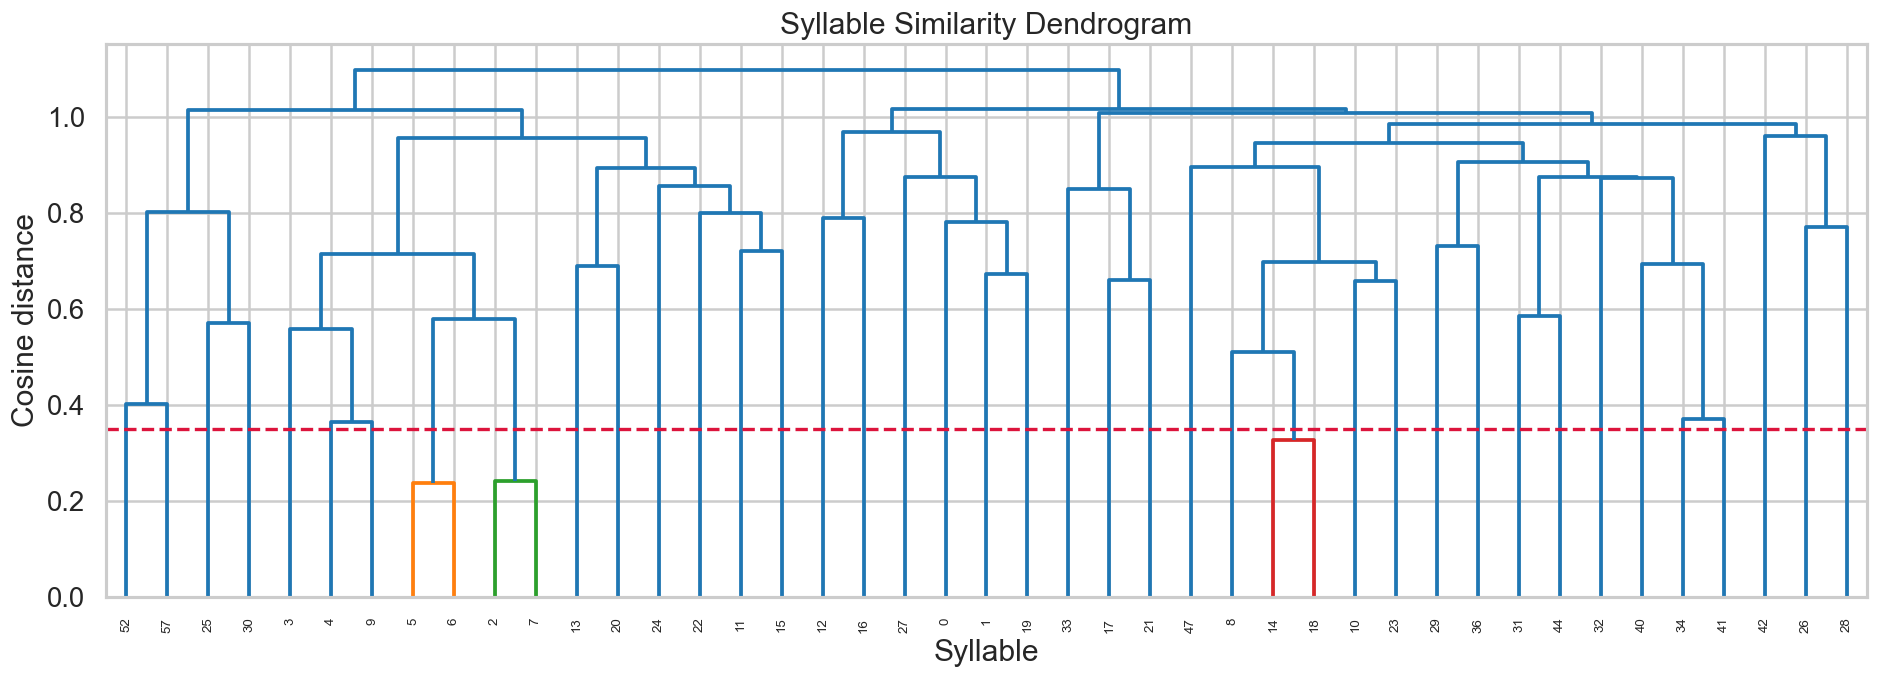

In [6]:
distance_vector = pdist(feature_scaled.to_numpy(dtype=float), metric=distance_metric)
linkage_matrix = linkage(distance_vector, method=linkage_method)
distance_matrix = pd.DataFrame(
    squareform(distance_vector),
    index=syllables,
    columns=syllables,
)
similarity_matrix = 1 - distance_matrix

plt.figure(figsize=(16, 6))
dendrogram(
    linkage_matrix,
    labels=[str(s) for s in syllables],
    color_threshold=cluster_distance_threshold,
)
plt.axhline(cluster_distance_threshold, color="crimson", linestyle="--", linewidth=2)
plt.title("Syllable Similarity Dendrogram")
plt.xlabel("Syllable")
plt.ylabel(f"{distance_metric.title()} distance")
plt.tight_layout()
plt.show()

distance_matrix.to_csv(output_dir / "syllable_distance_matrix.csv")
similarity_matrix.to_csv(output_dir / "syllable_similarity_matrix.csv")


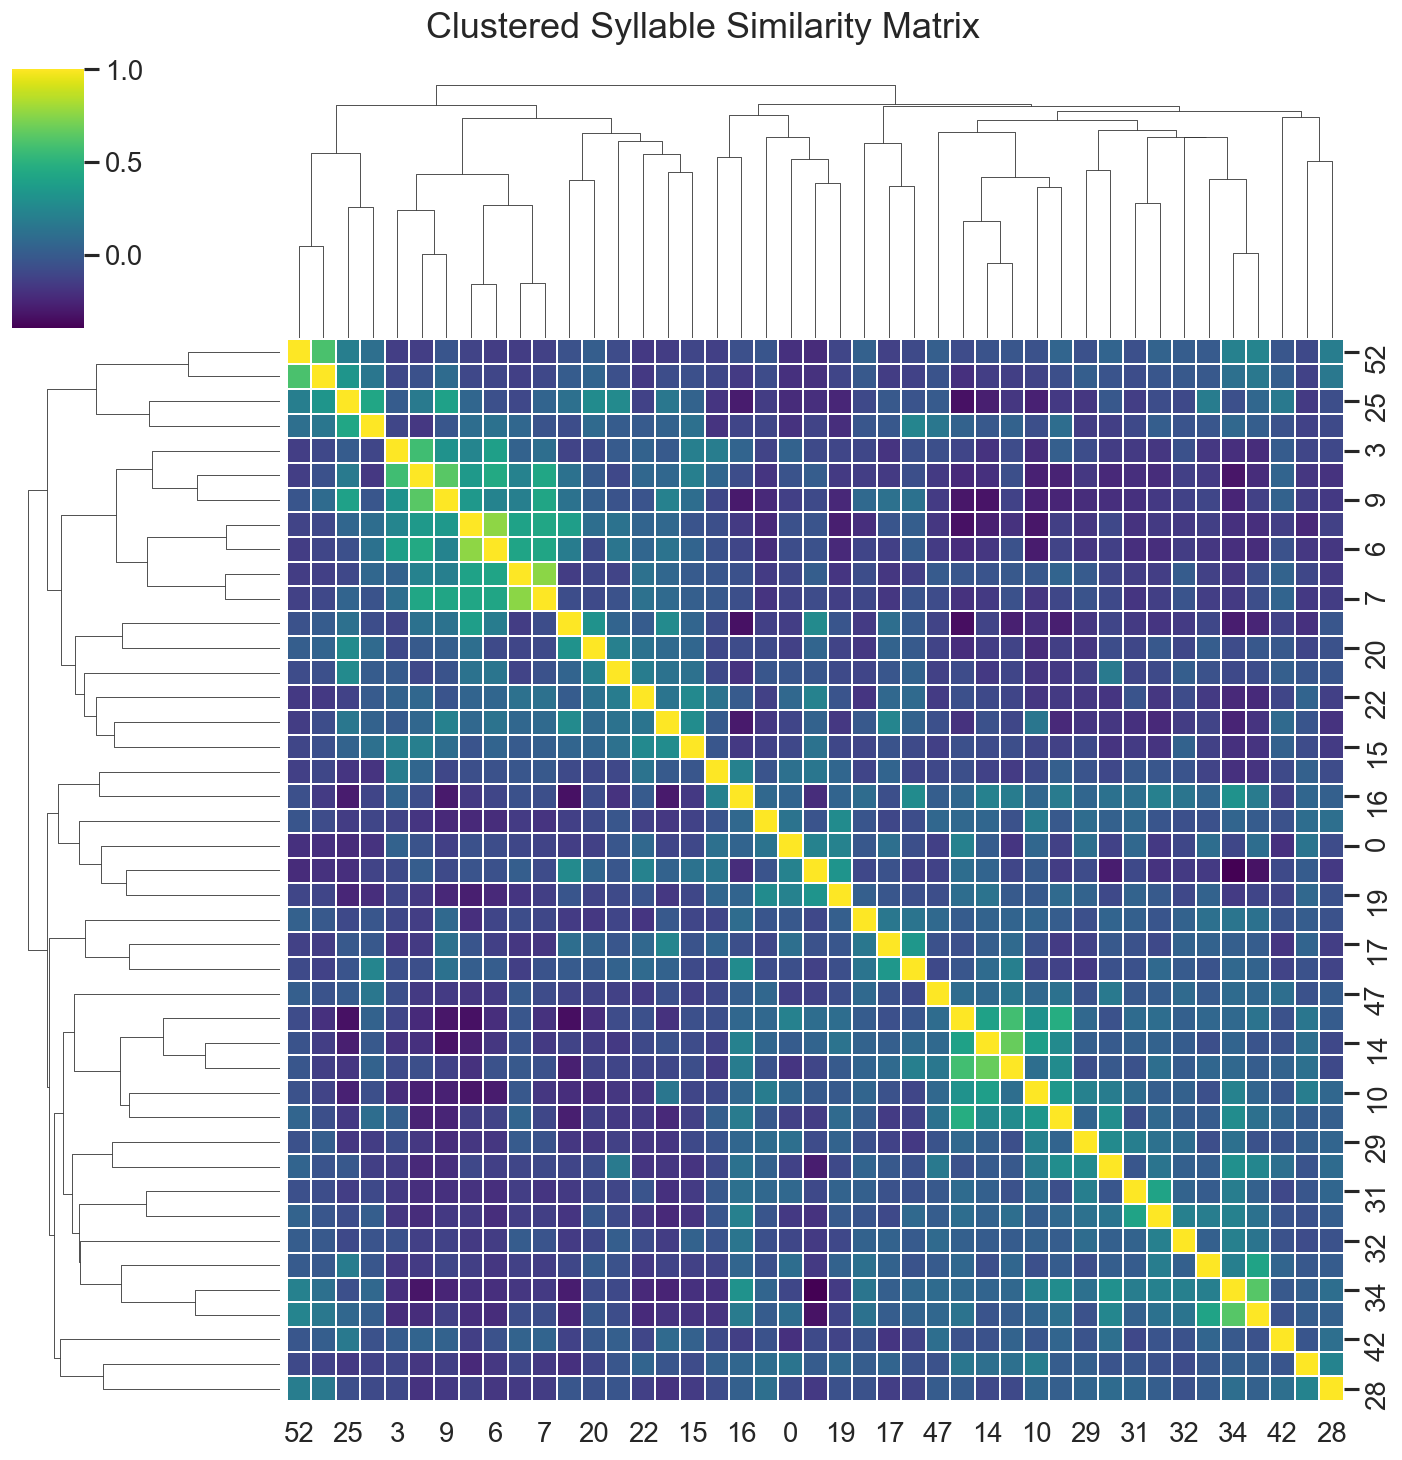

In [7]:
g = sns.clustermap(
    similarity_matrix,
    row_linkage=linkage_matrix,
    col_linkage=linkage_matrix,
    cmap="viridis",
    linewidths=0.2,
    figsize=(12, 12),
)
g.fig.suptitle("Clustered Syllable Similarity Matrix", y=1.02)
plt.show()


## Suggested Merge Groups From The Dendrogram Cut

In [8]:
cluster_labels = fcluster(linkage_matrix, t=cluster_distance_threshold, criterion="distance")
cluster_df = pd.DataFrame({"syllable": syllables, "cluster_id": cluster_labels})
cluster_df = cluster_df.merge(syllable_counts[["syllable", "n_frames", "fraction_frames"]], on="syllable", how="left")

suggested_groups = (
    cluster_df.sort_values(["cluster_id", "n_frames"], ascending=[True, False])
    .groupby("cluster_id", observed=True)["syllable"]
    .apply(list)
    .reset_index(name="suggested_merge_group")
)
suggested_groups["group_size"] = suggested_groups["suggested_merge_group"].str.len()
suggested_groups = suggested_groups.sort_values(["group_size", "cluster_id"], ascending=[False, True]).reset_index(drop=True)

display(cluster_df.sort_values(["cluster_id", "n_frames"], ascending=[True, False]).head(50))
display(suggested_groups[suggested_groups["group_size"] > 1])

cluster_df.to_csv(output_dir / "syllable_cluster_assignments.csv", index=False)
suggested_groups.to_csv(output_dir / "suggested_merge_groups.csv", index=False)


,syllable,cluster_id,n_frames,fraction_frames
41,52,1,623,0.001650
42,57,2,655,0.001735
25,25,3,7655,0.020276
30,30,4,617,0.001634
4,4,5,39201,0.103834
9,9,6,37726,0.099927
3,3,7,11652,0.030863
5,5,8,59736,0.158226
6,6,8,39494,0.104610
7,7,9,10802,0.028612


,cluster_id,suggested_merge_group,group_size
0,8,"[5, 6]",2
1,9,"[7, 2]",2
2,25,"[14, 18]",2


## Review Candidate Groups

Tip: compare these groups against the PDFs and GIFs in `trajectory_plots` before deciding to merge.

Examples live in files like:

- `trajectory_plots/Syllable4.pdf`
- `trajectory_plots/Syllable4.gif`


In [9]:
candidate_cluster_id = int(suggested_groups.loc[suggested_groups["group_size"] > 1, "cluster_id"].iloc[0]) if (suggested_groups["group_size"] > 1).any() else None

if candidate_cluster_id is None:
    print("No multi-syllable groups were suggested at the current threshold.")
else:
    candidate_syllables = cluster_df.loc[cluster_df["cluster_id"] == candidate_cluster_id, "syllable"].tolist()
    review_df = cluster_df.loc[cluster_df["syllable"].isin(candidate_syllables)].sort_values("n_frames", ascending=False)
    display(review_df)
    for syllable in candidate_syllables:
        print(f"Syllable {syllable}: {trajectory_plot_dir / f'Syllable{syllable}.pdf'}")


,syllable,cluster_id,n_frames,fraction_frames
5,5,8,59736,0.158226
6,6,8,39494,0.104610


Syllable 5: c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Keypoint_moseq_analysis\keypoint_moseq_project_home_cage\2026_05_13-23_29_52\trajectory_plots\Syllable5.pdf
Syllable 6: c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Keypoint_moseq_analysis\keypoint_moseq_project_home_cage\2026_05_13-23_29_52\trajectory_plots\Syllable6.pdf


## Find Candidate Matches For Low-Occupancy Tail Syllables

Instead of merging rare syllables automatically, this section finds the most similar higher-occupancy syllable for each low-occupancy syllable.

The cutoff is based on cumulative occupancy. By default, any syllable outside the top `0.99` cumulative occupancy is treated as a candidate for manual review.

In [9]:
occupancy_keep_threshold = 0.99

ranked_summary = syllable_counts.copy()
ranked_summary["occupancy_rank"] = np.arange(1, len(ranked_summary) + 1)
ranked_summary["keep_by_occupancy"] = ranked_summary["cumulative_fraction"] <= occupancy_keep_threshold

if not ranked_summary.empty:
    ranked_summary.loc[ranked_summary.index[0], "keep_by_occupancy"] = True

kept_syllables = ranked_summary.loc[ranked_summary["keep_by_occupancy"], "syllable"].tolist()
tail_syllables = ranked_summary.loc[~ranked_summary["keep_by_occupancy"], "syllable"].tolist()

display(ranked_summary)
print(f"Occupancy threshold: {occupancy_keep_threshold}")
print("Kept syllables:")
print(kept_syllables)
print("Low-occupancy syllables to review:")
print(tail_syllables)
print(f"Total frame fraction in review tail: {ranked_summary.loc[~ranked_summary['keep_by_occupancy'], 'fraction_frames'].sum():.4f}")


,syllable,n_frames,fraction_frames,cumulative_fraction,occupancy_rank,keep_by_occupancy
0,13,86123,0.228119,0.228119,1,True
1,5,59736,0.158226,0.386345,2,True
2,6,39494,0.104610,0.490955,3,True
3,4,39201,0.103834,0.594788,4,True
4,9,37726,0.099927,0.694715,5,True
5,1,23315,0.061756,0.756471,6,True
6,3,11652,0.030863,0.787334,7,True
7,7,10802,0.028612,0.815946,8,True
8,2,10775,0.028540,0.844486,9,True
9,0,8583,0.022734,0.867221,10,True


Occupancy threshold: 0.99
Kept syllables:
[13, 5, 6, 4, 9, 1, 3, 7, 2, 0, 11, 25, 15, 20, 28, 12, 22, 8, 10, 24, 17, 16, 21, 19, 14, 18, 57]
Low-occupancy syllables to review:
[52, 30, 27, 33, 26, 23, 31, 42, 32, 41, 29, 34, 40, 47, 36, 44, 53, 39, 49, 35, 37, 54, 43, 38, 51, 45, 50, 56, 55, 48, 46]
Total frame fraction in review tail: 0.0101


In [10]:
candidate_rows = []
for tail_syllable in tail_syllables:
    if tail_syllable not in similarity_matrix.index:
        continue
    if not kept_syllables:
        continue

    similarity_to_kept = similarity_matrix.loc[tail_syllable, kept_syllables].sort_values(ascending=False)
    best_match = int(similarity_to_kept.index[0])
    best_similarity = float(similarity_to_kept.iloc[0])
    candidate_rows.append(
        {
            "tail_syllable": int(tail_syllable),
            "best_match_syllable": best_match,
            "best_similarity": best_similarity,
            "tail_fraction_frames": float(ranked_summary.loc[ranked_summary['syllable'].eq(tail_syllable), 'fraction_frames'].iloc[0]),
            "tail_cumulative_fraction": float(ranked_summary.loc[ranked_summary['syllable'].eq(tail_syllable), 'cumulative_fraction'].iloc[0]),
        }
    )

candidate_match_df = pd.DataFrame(candidate_rows).sort_values(
    ["best_similarity", "tail_fraction_frames"],
    ascending=[False, False],
).reset_index(drop=True)

if not candidate_match_df.empty:
    candidate_match_df["tail_pdf"] = candidate_match_df["tail_syllable"].map(lambda s: str(trajectory_plot_dir / f"Syllable{s}.pdf"))
    candidate_match_df["match_pdf"] = candidate_match_df["best_match_syllable"].map(lambda s: str(trajectory_plot_dir / f"Syllable{s}.pdf"))

display(candidate_match_df)
candidate_match_df.to_csv(output_dir / "low_occupancy_candidate_matches.csv", index=False)


,tail_syllable,best_match_syllable,best_similarity,tail_fraction_frames,tail_cumulative_fraction,tail_pdf,match_pdf
0,52,57,0.597605,0.001650,0.991585,c:\Users\alber\OneDrive\Documents\GitHub\Fiber...,c:\Users\alber\OneDrive\Documents\GitHub\Fiber...
1,23,8,0.468128,0.000853,0.997047,c:\Users\alber\OneDrive\Documents\GitHub\Fiber...,c:\Users\alber\OneDrive\Documents\GitHub\Fiber...
2,30,25,0.428599,0.001634,0.993219,c:\Users\alber\OneDrive\Documents\GitHub\Fiber...,c:\Users\alber\OneDrive\Documents\GitHub\Fiber...
3,34,16,0.312259,0.000162,0.999123,c:\Users\alber\OneDrive\Documents\GitHub\Fiber...,c:\Users\alber\OneDrive\Documents\GitHub\Fiber...
4,27,19,0.270669,0.001062,0.994281,c:\Users\alber\OneDrive\Documents\GitHub\Fiber...,c:\Users\alber\OneDrive\Documents\GitHub\Fiber...
5,26,28,0.229342,0.000869,0.996194,c:\Users\alber\OneDrive\Documents\GitHub\Fiber...,c:\Users\alber\OneDrive\Documents\GitHub\Fiber...
6,29,10,0.210596,0.000185,0.998962,c:\Users\alber\OneDrive\Documents\GitHub\Fiber...,c:\Users\alber\OneDrive\Documents\GitHub\Fiber...
7,44,16,0.206657,0.000069,0.999473,c:\Users\alber\OneDrive\Documents\GitHub\Fiber...,c:\Users\alber\OneDrive\Documents\GitHub\Fiber...
8,40,25,0.183297,0.000117,0.999240,c:\Users\alber\OneDrive\Documents\GitHub\Fiber...,c:\Users\alber\OneDrive\Documents\GitHub\Fiber...
9,36,10,0.182923,0.000072,0.999404,c:\Users\alber\OneDrive\Documents\GitHub\Fiber...,c:\Users\alber\OneDrive\Documents\GitHub\Fiber...


## Define Manual Merge Groups

Edit `syllables_to_merge` after reviewing the dendrogram, the clustered heatmap, the candidate match table above, and the trajectory plots.

In [16]:
# Example only. Replace with your chosen groups.
# These are syllables that are low occupancy at ttop, similar syllables at below
syllables_to_merge = [
    [52, 57],
    [8, 23],
    [25, 30],
    [16,34],
    [19,27],
    [26,28],
    [10,29],

    [26,28],
    [16,44], # More iffy on these but they contribute to so little frames
    [25,40],
    [10,36],
    [16,41],
    [25,42],
    [17,33],
    [18,47],

    [2,7],
    [5,6],
    [14,18]
]

syllables_to_merge


[[52, 57],
 [8, 23],
 [25, 30],
 [16, 34],
 [19, 27],
 [26, 28],
 [10, 29],
 [26, 28],
 [16, 44],
 [25, 40],
 [10, 36],
 [16, 41],
 [25, 42],
 [17, 33],
 [18, 47],
 [2, 7],
 [5, 6],
 [14, 18]]

In [18]:
def build_merge_mapping(all_syllables, merge_groups):
    mapping = {int(s): int(s) for s in all_syllables}
    for group in merge_groups:
        if len(group) < 2:
            continue
        group = sorted(int(s) for s in group)
        target = group[0]
        for s in group:
            mapping[s] = target
    return mapping


merge_mapping = build_merge_mapping(sorted(frames["syllable"].dropna().unique()), syllables_to_merge)
mapping_preview = pd.DataFrame({
    "old_syllable": sorted(merge_mapping),
    "new_syllable": [merge_mapping[s] for s in sorted(merge_mapping)],
})
mapping_preview = mapping_preview.loc[mapping_preview["old_syllable"] != mapping_preview["new_syllable"]].reset_index(drop=True)
display(mapping_preview)


,old_syllable,new_syllable
0,6,5
1,7,2
2,18,14
3,23,8
4,27,19
5,28,26
6,29,10
7,30,25
8,33,17
9,34,16


## Preview Merged Occupancy In `syllable_frames`

This preview works even if `keypoint_moseq` is not installed.

In [19]:
frames_merged_preview = frames.copy()
frames_merged_preview["syllable_merged"] = frames_merged_preview["syllable"].map(merge_mapping).fillna(frames_merged_preview["syllable"]).astype(int)

merged_counts = (
    frames_merged_preview.groupby("syllable_merged", observed=True)
    .size()
    .rename("n_frames")
    .sort_values(ascending=False)
    .reset_index()
)
merged_counts["fraction_frames"] = merged_counts["n_frames"] / merged_counts["n_frames"].sum()

display(merged_counts.head(20))
merged_counts.to_csv(output_dir / "merged_syllable_occupancy_preview.csv", index=False)


,syllable_merged,n_frames,fraction_frames
0,5,99230,0.262836
1,13,86123,0.228119
2,4,39201,0.103834
3,9,37726,0.099927
4,1,23315,0.061756
5,2,21577,0.057152
6,3,11652,0.030863
7,0,8583,0.022734
8,25,8483,0.022469
9,11,8469,0.022432


## Optionally Save Merged `results.h5`

This keeps the original `results.h5` unchanged and writes merged outputs to new files.

In [21]:
save_merged_results = True

if save_merged_results:
    if kpms is None:
        raise ImportError("keypoint_moseq is required to save merged results.h5 outputs.")

    if not syllables_to_merge:
        raise ValueError("Define at least one merge group before saving merged results.")

    results = kpms.load_hdf5(results_path)
    syllable_mapping = kpms.generate_syllable_mapping(results, syllables_to_merge)
    merged_results = kpms.apply_syllable_mapping(results, syllable_mapping)

    merged_results_path = model_dir / "results_merged.h5"
    kpms.save_hdf5(merged_results_path, merged_results)

    mapping_out = output_dir / "syllable_merge_mapping.csv"
    pd.DataFrame(
        {
            "old_syllable": sorted(syllable_mapping),
            "new_syllable": [syllable_mapping[s] for s in sorted(syllable_mapping)],
        }
    ).to_csv(mapping_out, index=False)

    print(f"Saved merged results to: {merged_results_path}")
    print(f"Saved merge mapping to: {mapping_out}")
else:
    print("Set save_merged_results = True after you are happy with the merge groups.")


Saved merged results to: c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Keypoint_moseq_analysis\keypoint_moseq_project_home_cage\2026_05_13-23_29_52\results_merged.h5
Saved merge mapping to: c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Keypoint_moseq_analysis\keypoint_moseq_project_home_cage\2026_05_13-23_29_52\syllable_dendrogram_merge_analysis\syllable_merge_mapping.csv


In [22]:
frames_merged = frames.copy()
frames_merged["syllable"] = (
    frames_merged["syllable"]
    .map(merge_mapping)
    .fillna(frames_merged["syllable"])
    .astype(int)
)

merged_syllable_frames_path = model_dir / "syllable_frames_merged.csv"
frames_merged.to_csv(merged_syllable_frames_path, index=False)

print(f"Saved merged syllable frames to: {merged_syllable_frames_path}")

Saved merged syllable frames to: c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Keypoint_moseq_analysis\keypoint_moseq_project_home_cage\2026_05_13-23_29_52\syllable_frames_merged.csv
